## 3. AutoGluon Configuration Analysis

This notebook investigates how AutoGluon's internal configuration affects predictive performance. Preset quality, stack levels, and bagging folds are varied independently to test whether increased complexity leads to better performance (Sub-question 1).

### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, f1_score
from autogluon.tabular import TabularPredictor
from utils import load_and_preprocess, get_train_test_split

os.makedirs('figures', exist_ok=True)
SEEDS = [0, 1, 2, 3, 4]
plt.rcParams['font.size'] = 12
print('Setup complete!')

Setup complete!


### Data Loading

In [2]:
_, X_auto, y = load_and_preprocess('Churn_Modelling.csv')
print(f'Features: {X_auto.shape[1]}, Samples: {X_auto.shape[0]}')

Features: 10, Samples: 10000


### Preset Quality Comparison
Compare medium_quality and high_quality presets. Higher quality presets train more diverse models but require more time.

In [3]:
presets = ['medium_quality', 'high_quality']
preset_results = []

for preset in presets:
    auc_scores, train_times = [], []
    for seed in SEEDS:
        X_train, X_test, y_train, y_test = get_train_test_split(X_auto, y, seed)
        train_data = X_train.copy()
        train_data['Exited'] = y_train.values
        save_path = f'agmodels/preset_{preset}_seed_{seed}'
        if os.path.exists(save_path): shutil.rmtree(save_path)
        start = time.time()
        predictor = TabularPredictor(label='Exited', path=save_path, verbosity=0)
        predictor.fit(train_data, time_limit=120, presets=preset)
        train_times.append(time.time() - start)
        y_prob = predictor.predict_proba(X_test)[1]
        auc_scores.append(roc_auc_score(y_test, y_prob))
        shutil.rmtree(save_path)
    preset_results.append({'preset': preset, 'auc_mean': np.mean(auc_scores),
                           'auc_std': np.std(auc_scores), 'train_time': np.mean(train_times)})
    print(f'{preset}: AUC={np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}, Train={np.mean(train_times):.0f}s')

import pandas as pd
preset_df = pd.DataFrame(preset_results)

medium_quality: AUC=0.8610 ± 0.0077, Train=22s
high_quality: AUC=0.8643 ± 0.0073, Train=125s


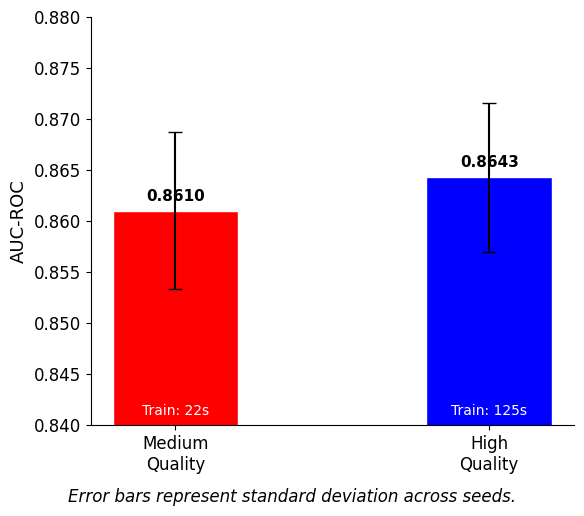

In [5]:
# Figure 6: Preset Comparison
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Medium\nQuality', 'High\nQuality'], preset_df['auc_mean'].values,
              yerr=preset_df['auc_std'].values, color=['red', 'blue'],
              edgecolor='white', capsize=5, width=0.4)
ax.set_ylabel('AUC-ROC', fontsize=13)
ax.set_ylim(0.84, 0.88)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, v, t in zip(bars, preset_df['auc_mean'].values, preset_df['train_time'].values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
            f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, 0.841,
            f'Train: {t:.0f}s', ha='center', fontsize=10, color='white')
fig.text(0.5, -0.02, 'Error bars represent standard deviation across seeds.',
         ha='center', fontsize=12, style='italic')
plt.tight_layout()
plt.savefig('figures/figure6_preset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Stack Levels
Test stack levels 1, 2, and 3 to see if deeper stacking improves performance.

In [6]:
stack_results = []
for stack in [1, 2, 3]:
    auc_scores = []
    for seed in SEEDS:
        X_train, X_test, y_train, y_test = get_train_test_split(X_auto, y, seed)
        train_data = X_train.copy()
        train_data['Exited'] = y_train.values
        save_path = f'agmodels/stack_{stack}_seed_{seed}'
        if os.path.exists(save_path): shutil.rmtree(save_path)
        predictor = TabularPredictor(label='Exited', path=save_path, verbosity=0)
        predictor.fit(train_data, time_limit=120, presets='high_quality', num_stack_levels=stack)
        auc_scores.append(roc_auc_score(y_test, predictor.predict_proba(X_test)[1]))
        shutil.rmtree(save_path)
    stack_results.append({'stack_level': stack, 'auc_mean': np.mean(auc_scores), 'auc_std': np.std(auc_scores)})
    print(f'Stack {stack}: AUC={np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')
stack_df = pd.DataFrame(stack_results)

Stack 1: AUC=0.8635 ± 0.0066
Stack 2: AUC=0.8614 ± 0.0068
Stack 3: AUC=0.8597 ± 0.0059


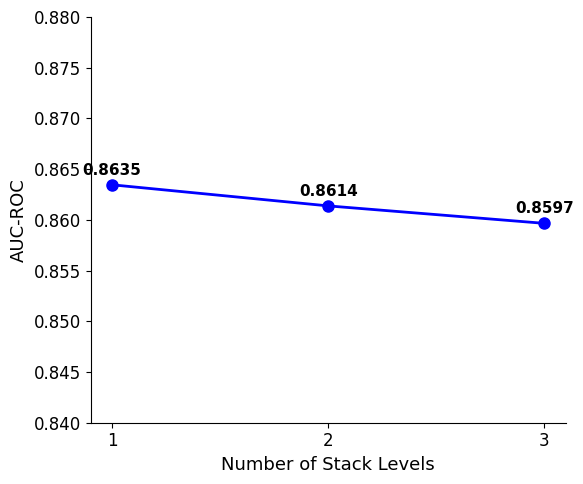

In [7]:
# Figure 7: Stack Levels
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([1, 2, 3], stack_df['auc_mean'], color='blue', marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Number of Stack Levels', fontsize=13)
ax.set_ylabel('AUC-ROC', fontsize=13)
ax.set_xticks([1, 2, 3])
ax.set_ylim(0.84, 0.88)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for xi, yi in zip([1, 2, 3], stack_df['auc_mean']):
    ax.text(xi, yi + 0.001, f'{yi:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/figure7_stack_levels.png', dpi=150, bbox_inches='tight')
plt.show()

### Bagging Folds
Test bagging folds 3, 5, and 8 to evaluate the effect of ensemble diversity.

In [8]:
bagging_results = []
for folds in [3, 5, 8]:
    auc_scores = []
    for seed in SEEDS:
        X_train, X_test, y_train, y_test = get_train_test_split(X_auto, y, seed)
        train_data = X_train.copy()
        train_data['Exited'] = y_train.values
        save_path = f'agmodels/bag_{folds}_seed_{seed}'
        if os.path.exists(save_path): shutil.rmtree(save_path)
        predictor = TabularPredictor(label='Exited', path=save_path, verbosity=0)
        predictor.fit(train_data, time_limit=120, presets='high_quality', num_bag_folds=folds)
        auc_scores.append(roc_auc_score(y_test, predictor.predict_proba(X_test)[1]))
        shutil.rmtree(save_path)
    bagging_results.append({'bagging_folds': folds, 'auc_mean': np.mean(auc_scores), 'auc_std': np.std(auc_scores)})
    print(f'Folds {folds}: AUC={np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')
bagging_df = pd.DataFrame(bagging_results)

Folds 3: AUC=0.8655 ± 0.0058
Folds 5: AUC=0.8638 ± 0.0033
Folds 8: AUC=0.8617 ± 0.0048


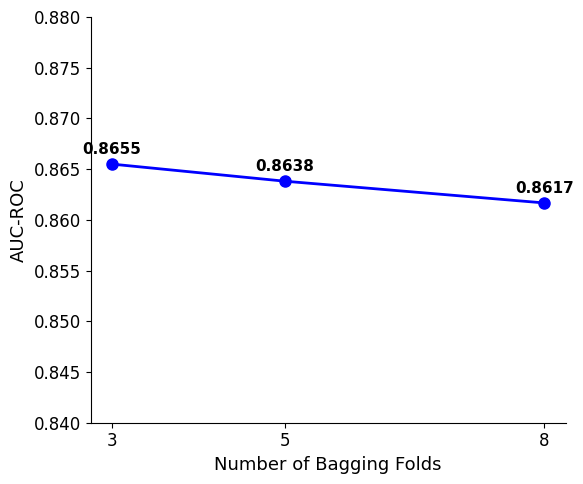

In [9]:
# Figure 8: Bagging Folds
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([3, 5, 8], bagging_df['auc_mean'], color='blue', marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Number of Bagging Folds', fontsize=13)
ax.set_ylabel('AUC-ROC', fontsize=13)
ax.set_xticks([3, 5, 8])
ax.set_ylim(0.84, 0.88)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for xi, yi in zip([3, 5, 8], bagging_df['auc_mean']):
    ax.text(xi, yi + 0.001, f'{yi:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/figure8_bagging_folds.png', dpi=150, bbox_inches='tight')
plt.show()

## Key findings

- Increasing AutoGluon preset complexity led to only marginal improvements in AUC-ROC.
- Additional stack levels and bagging folds did not substantially improve predictive performance.
- These results suggest that, for this dataset, AutoGluon reaches a performance plateau relatively quickly.